# <mark style="display:block; background:#d1c4e9; color:#1a1a1a; padding:6px 12px; border-radius:4px">2주차 · 취향이 비슷한 사람끼리 묶는다</mark>

지난 시간에는 가장 많이 담긴 종목 10개를 300명 모두에게 똑같이 보여 주었습니다.

점수는 0.2163이 나왔고, 알고리즘을 하나도 쓰지 않은 것 치고는 나쁘지 않았습니다.

그런데 마지막에 문제를 하나 보았습니다.

원금을 지키는 것이 최우선인 투자자와 레버리지 상품까지 담는 투자자에게, 우리는 **같은 근거로 만든 같은 목록**을 내밀었습니다.

오늘은 이 문제를 풉니다.

그 사람이 지금까지 담아 온 것을 보고 취향을 짐작해서, 사람마다 다른 목록을 만듭니다.

그리고 추천을 채점하는 방법이 하나가 아니라는 것을 알아보고, 세 가지 지표를 직접 계산해 봅니다.

---

### 오늘의 구성

| 파트 | 종류 | 시간 | 하는 일 |
|---|---|---|---|
| 1 | 개념 | 10분 | 지난 시간의 한계를 다시 보고, 무엇이 더 필요한지 정리합니다 |
| 2 | 실습 | 10분 | 거래 기록에서 주력 섹터와 평균 위험도를 뽑아 사람을 묶습니다 |
| 3 | 개념 | 10분 | 채점하는 방법 세 가지를 배웁니다 |
| 4 | 실습 | 10분 | 세 지표를 직접 계산하고 1주차와 비교합니다 |
| — | 질문 | 10분 | 노트북을 덮고 이야기합니다 |

### 강사용 · 예상 소요 시간

- 전체 셀을 처음부터 끝까지 실행 — **약 12초**
- 가장 오래 걸리는 셀은 마지막 비교 셀로 약 6초입니다.
- 첫 셀의 `import` 가 3~5초 걸리므로 **수업 시작 전에 미리 한 번 실행**해 두시길 권합니다.

## <mark style="display:block; background:#c8e6c9; color:#1a1a1a; padding:6px 12px; border-radius:4px">시작하기 · 이 노트북을 여는 법</mark>

이 노트북은 **아무것도 설치하지 않고** 브라우저에서 바로 실행할 수 있습니다.

데이터도 따로 내려받지 않습니다. 아래 준비 셀이 알아서 가져옵니다.

### Google Colab 으로 열기

1. 아래 주소를 눌러 주세요.
   - https://colab.research.google.com/github/welovecherry/recsys/blob/main/notebooks/02_rules_metrics.ipynb
2. 구글 계정으로 로그인합니다.
   - 이미 로그인돼 있으면 이 단계는 그냥 지나갑니다.
3. **경고창이 뜨면 `Run anyway` 를 누릅니다.**
   - `Warning: This notebook was not authored by Google` 이라는 문구가 나옵니다.
   - 강사가 만든 파일이니 **`Run anyway`(그래도 실행)** 를 누르시면 됩니다.
4. **아래 "실습 준비" 셀의 ▶ 버튼을 누릅니다.**
   - 실습에 필요한 자료와 한글 글꼴을 받아옵니다. 20초쯤 걸립니다.
   - "준비 끝" 이 나오면 성공입니다.
5. 그다음부터는 위에서 아래로 셀을 하나씩 실행하면 됩니다.

> ⚠ **고친 내용을 남기려면** 메뉴에서 `파일 → 드라이브에 사본 저장` 을 눌러 주세요.
> 누르지 않으면 탭을 닫을 때 사라집니다.

---

### <mark style="display:block; background:#c8e6c9; color:#1a1a1a; padding:6px 12px; border-radius:4px">먼저 이 셀부터 실행하세요  ▶</mark>


In [1]:
# 이 셀의 목적 — Colab 이면 실습 자료와 한글 글꼴을 받아온다
# ── 실습 준비 ─────────────────────────────────────────────
# Colab 에서 열었을 때만 자료를 내려받습니다.
# 내 컴퓨터에서 열었다면 아무 일도 하지 않고 넘어갑니다.
import os          # 폴더를 만들고 옮겨 다니는 도구
import sys         # 지금 파이썬이 어떤 환경인지 알려 주는 도구
import subprocess  # 터미널 명령을 파이썬에서 대신 실행해 주는 도구

if "google.colab" in sys.modules:          # Colab 이면 이 안이 실행된다
    print("Colab 입니다. 실습 자료를 받아옵니다 ...")

    if not os.path.exists("/content/recsys"):        # 아직 안 받았을 때만
        subprocess.run(["git", "clone", "-q",        # 깃허브에서 통째로 내려받기
                        "https://github.com/welovecherry/recsys.git",
                        "/content/recsys"])
    os.chdir("/content/recsys/notebooks")            # 노트북 폴더 안으로 이동
    print("  자료 받기 완료 —", os.getcwd())

    print("한글 글꼴을 설치합니다 ...")
    subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-nanum"],   # 나눔고딕 설치
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)  # 설치 로그는 숨김

    # 새로 깐 글꼴을 matplotlib 이 알아보도록 글꼴 목록을 다시 읽게 합니다.
    subprocess.run(["rm", "-rf", os.path.expanduser("~/.cache/matplotlib")])
    print("  글꼴 설치 완료")

    print()
    print("준비 끝. 아래 셀부터 차례로 실행하세요.")
else:                                                 # 내 컴퓨터일 때
    print("내 컴퓨터에서 실행 중입니다. 따로 받아올 것이 없습니다.")
    print("지금 폴더:", os.getcwd())


내 컴퓨터에서 실행 중입니다. 따로 받아올 것이 없습니다.
지금 폴더: /Users/hong/workspaces/org_physical-spark/course-recsys/notebooks


## <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1 · 개념 — 무엇이 더 필요한가</mark>

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.1 지난 시간이 남긴 문제  `[PPT]`</mark>

지난 시간 마지막에 두 사람의 추천 목록을 나란히 놓아 보았습니다.

한 사람은 원금을 지키는 것이 최우선인 투자자였고, 다른 한 사람은 손실을 감수하고 큰 수익을 노리는 투자자였습니다.

두 목록에 차이가 있긴 했지만, 그것은 **이미 담은 종목을 걸러낸 결과**였을 뿐입니다.

순위표는 하나뿐이었고 두 사람 모두 그 표를 위에서부터 받았습니다.

추천의 근거가 사람에 따라 달라진 것이 아닙니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.2 사람마다 다르게 하려면 무엇이 필요한가  `[PPT]`</mark>

사람마다 다른 추천을 하려면 **그 사람이 어떤 사람인지**를 알아야 합니다.

그런데 그걸 어떻게 알아낼까요.

1. **직접 물어보기** — 가입할 때 투자 성향 설문을 받습니다.
   - 실제 금융 회사가 하는 방식입니다.
   - 다만 설문에서 안정형이라고 답한 사람이 레버리지 상품을 사는 일은 아주 흔합니다.
   - 그리고 우리가 앞으로 쓸 데이터에는 그런 설문 결과가 아예 없는 경우가 많습니다.
2. **행동을 보기** — 그 사람이 지금까지 담아 온 것을 봅니다.
   - 반도체 종목만 담아 온 사람에게는 반도체에서 인기 있는 것을 주면 됩니다.
   - 말보다 행동이 정직합니다.
   - 오늘은 이 방법으로 갑니다.

`users.csv` 파일에는 사실 투자 성향이 적혀 있습니다.

하지만 오늘 그것을 **쓰지 않습니다.**

그 값은 이 연습용 데이터를 만들 때 심어 둔 정답지이고, 그것을 쓰면 답을 보고 문제를 푸는 셈이 되기 때문입니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.3 오늘 만들 것 — 규칙 기반 추천  `[PPT]`</mark>

오늘 만들 방식을 **규칙 기반 추천**이라고 부릅니다.

모델을 학습시키지 않고 사람이 정한 규칙만으로 만드는 방식입니다.

1. 사람마다 거래 기록을 보고 **주력 섹터**를 찾습니다.
2. 같은 기록에서 **평균 위험도**도 구합니다.
3. 두 값을 합쳐 무리 이름을 만듭니다. 예를 들면 `Semiconductor|4` 같은 것입니다.
4. 무리마다 인기 순위표를 따로 만들고, 각자 자기 무리의 목록을 받습니다.

같은 무리에 속한 사람끼리는 여전히 같은 목록을 받습니다.

그래도 300명 전원이 같은 목록을 받던 지난주보다는 나아집니다.

## <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2 · 실습 — 사람을 무리로 묶는다</mark>

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.1 오늘 나오는 말  `[PPT]`</mark>

1. **섹터 (sector)** — 종목이 속한 산업 분야
   - 반도체 · 배당 · 채권 · 레버리지처럼 성격이 비슷한 종목을 묶은 이름입니다.
   - `items.csv` 의 `sector` 칸에 들어 있습니다.
2. **위험도 (risk_level)** — 그 종목이 얼마나 크게 오르내리는지를 1~5로 매긴 숫자
   - 1은 국채처럼 잘 안 움직이는 것, 5는 레버리지처럼 크게 흔들리는 것입니다.
   - `items.csv` 의 `risk_level` 칸에 들어 있습니다.
3. **세그먼트 (segment)** — 취향이 비슷하다고 판단한 사람들의 묶음
   - 실무에서 **사용자 세그먼테이션**이라고 부르는 그 작업입니다.
   - 아래 코드에서는 우리말로 `무리` 라고 적었습니다. 같은 말입니다.
   - 오늘은 `주력섹터|평균위험도` 형태의 문자열을 무리 이름으로 씁니다.
   - 같은 이름을 가진 사람들이 한 무리입니다.
4. **피처 (feature)** — 사람이나 상품을 설명하려고 데이터에서 뽑아낸 값
   - 오늘 만드는 **주력 섹터**와 **평균 위험도**가 바로 피처입니다.
   - 이 피처 두 개로 세그먼트를 나눕니다.
5. **매핑 (mapping)** — 어떤 값을 다른 값으로 바꿔 주는 것
   - 종목 번호 `I044` 를 넣으면 섹터 `Semiconductor` 가 나오게 하는 일입니다.
   - 지난 시간에 만든 "번호 → 이름" 사전과 같은 원리입니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.2 준비 — 지난 시간 것을 다시 불러온다</mark>

지난 시간에 한 일을 그대로 다시 합니다.

데이터를 읽고, 시간으로 나누고, 종목 번호를 이름으로 바꿔 주는 사전을 만듭니다.

지난 시간에 했던 것이므로 설명 없이 한 번에 실행합니다.

In [2]:
# 준비 — 필요한 도구를 불러옵니다.
import sys

sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import recsys

# 그래프의 한글이 깨지지 않도록, 이 컴퓨터에 실제로 깔려 있는 글꼴 중에서 고릅니다.
from matplotlib import font_manager

설치된_글꼴 = {f.name for f in font_manager.fontManager.ttflist}
후보 = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR"]
고른_글꼴 = next((이름 for 이름 in 후보 if 이름 in 설치된_글꼴), None)

if 고른_글꼴:
    matplotlib.rcParams["font.family"] = 고른_글꼴
    matplotlib.rcParams["axes.unicode_minus"] = False
    print(f"한글 글꼴: {고른_글꼴}")
else:
    print("한글 글꼴을 못 찾았습니다. 그래프의 한글이 네모로 보일 수 있습니다.")
    print("맥은 기본 설치돼 있고, 윈도우는 '맑은 고딕'이 있으면 됩니다.")

print("준비 완료")

한글 글꼴: AppleGothic
준비 완료


In [3]:
# 데이터를 읽고 시간으로 나눕니다. 지난 시간과 똑같습니다.
items, users, inter = recsys.load()
train, test, cut = recsys.split_by_time(inter)

# 종목 번호를 이름으로 바꿔 주는 사전 (지난 시간에 만든 것)
종목표_번호색인 = items.set_index("item_id")
name_of = 종목표_번호색인["name"].to_dict()

# 사람마다 학습 구간에서 이미 담은 종목들
사람별_담은종목 = train.groupby("user_id")["item_id"].apply(set)
seen_map = 사람별_담은종목.to_dict()

# 지난 시간의 추천 방식 — 누가 오든 인기 순위표 위에서부터 10개
종목별_거래건수 = train["item_id"].value_counts()
인기순위 = list(종목별_거래건수.index)


def 모두에게_같은_추천(user_id, seen):
    return recsys.take(인기순위, seen)


지난시간_점수, _ = recsys.recall_at_k(모두에게_같은_추천, train, test)

print(f"학습 {len(train):,}건 · 채점 {len(test):,}건")
print(f"지난 시간 방식의 점수  Recall@10 = {지난시간_점수:.4f}")

학습 7,095건 · 채점 991건
지난 시간 방식의 점수  Recall@10 = 0.2163


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.3 거래 기록에 종목 정보를 붙인다</mark>

거래 기록에는 종목 번호만 있습니다.

섹터와 위험도는 종목 표에 있으니, 번호를 보고 가져다 붙여야 합니다.

먼저 "번호 → 섹터" 와 "번호 → 위험도" 사전을 각각 만듭니다.

지난 시간에 "번호 → 이름" 사전을 만든 것과 똑같은 방법입니다.

In [4]:
# 섹터 사전 — 종목 번호를 넣으면 섹터가 나옵니다.
섹터_열 = 종목표_번호색인["sector"]     # DataFrame 에서 열 하나만 → Series
섹터_of = 섹터_열.to_dict()             # Series → dict

# 위험도 사전 — 같은 방법으로 하나 더
위험도_열 = 종목표_번호색인["risk_level"]
위험도_of = 위험도_열.to_dict()

print(f"섹터 사전에 종목 {len(섹터_of)}개")
print()
print("I044 →", name_of["I044"], "· 섹터", 섹터_of["I044"], "· 위험도", 위험도_of["I044"])
print("I079 →", name_of["I079"], "· 섹터", 섹터_of["I079"], "· 위험도", 위험도_of["I079"])

섹터 사전에 종목 100개

I044 → Samsung Electronics · 섹터 Semiconductor · 위험도 3
I079 → KODEX Leverage · 섹터 Leveraged · 위험도 5


이제 이 사전으로 거래 기록에 섹터 열을 새로 붙입니다.

`.map()` 은 열의 값 하나하나를 사전에 넣어서 나온 결과로 바꿔 줍니다.

`I044` 가 들어가면 `Semiconductor` 가 나오는 식입니다.

In [5]:
# 1단계 — 거래 기록에서 종목 번호 열을 꺼냅니다.
거래_종목번호 = train["item_id"]

# 2단계 — 각 번호를 섹터 이름으로 바꿉니다.
거래_섹터 = 거래_종목번호.map(섹터_of)

# 3단계 — 원래 표에 그 열을 붙인 새 표를 만듭니다.
거래_섹터포함 = train.assign(sector=거래_섹터)

print("바꾸기 전 :", list(거래_종목번호.head(3)))
print("바꾼 뒤   :", list(거래_섹터.head(3)))
print()
거래_섹터포함.head()

바꾸기 전 : ['I043', 'I032', 'I008']
바꾼 뒤   : ['Index', 'Financials', 'Bond']



,user_id,item_id,ts,event,sector
0,U0245,I043,2025-08-31 10:00:00,view,Index
1,U0055,I032,2025-09-03 12:00:00,like,Financials
2,U0055,I008,2025-09-04 11:00:00,view,Bond
3,U0198,I084,2025-09-09 15:00:00,view,Leveraged
4,U0198,I090,2025-09-10 00:00:00,like,CleanEnergy


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.4 사람마다 주력 섹터를 찾는다</mark>

이제 사람별로 묶어서, 각자 가장 많이 담은 섹터를 하나 고릅니다.

`groupby("user_id")` 는 **같은 사람의 기록끼리 모아라**는 뜻입니다.

모은 다음 각 사람의 섹터 목록에서 가장 자주 나온 것을 뽑습니다.

In [6]:
def 가장_많은_값(값들):
    """여러 값 중 가장 자주 나온 것 하나를 돌려준다."""
    센_결과 = 값들.value_counts()   # 값별로 몇 번 나왔는지 세고 많은 순으로 정렬

    # ✏️ 빈칸 1 — 몇 번째를 가져와야 "가장 많은 것" 이 될까요?
    #    센_결과 는 이미 많은 순으로 정렬돼 있습니다. 이름은 .index 에 들어 있습니다.
    몇번째 = 0        # ← 이 숫자를 바꿔 보세요. 1 로 바꾸면 무엇이 나올까요?

    return 센_결과.index[몇번째]


# 사람별로 묶어서 섹터 열에 위 함수를 적용합니다.
사람별_묶음 = 거래_섹터포함.groupby("user_id")
사람별_섹터목록 = 사람별_묶음["sector"]
주력섹터_시리즈 = 사람별_섹터목록.agg(가장_많은_값)

주력섹터 = 주력섹터_시리즈.to_dict()

print(f"{len(주력섹터)}명의 주력 섹터를 구했습니다.")
print()
print("U0001 의 주력 섹터 :", 주력섹터["U0001"])
print("U0003 의 주력 섹터 :", 주력섹터["U0003"])

285명의 주력 섹터를 구했습니다.

U0001 의 주력 섹터 : Financials
U0003 의 주력 섹터 : Leveraged


한 사람만 자세히 뜯어봅니다.

`U0003` 이 담은 종목들의 섹터가 어떻게 분포하는지 보면, 왜 그 섹터가 뽑혔는지 알 수 있습니다.

In [7]:
그_사람의_거래 = 거래_섹터포함[거래_섹터포함["user_id"] == "U0003"]
그_사람의_섹터분포 = 그_사람의_거래["sector"].value_counts()

print(f"U0003 이 학습 구간에서 담은 종목 {len(그_사람의_거래)}건의 섹터 분포\n")
print(그_사람의_섹터분포)
print()
print("→ 가장 많은", 그_사람의_섹터분포.index[0], "가 주력 섹터로 뽑혔습니다.")

U0003 이 학습 구간에서 담은 종목 29건의 섹터 분포

sector
Leveraged        5
Index            4
Semiconductor    3
Battery          3
Thematic         2
Bond             1
Inverse          1
Dividend         1
Internet         1
Financials       1
Auto             1
Utilities        1
Gaming           1
Consumer         1
Technology       1
Defense          1
Software         1
Name: count, dtype: int64

→ 가장 많은 Leveraged 가 주력 섹터로 뽑혔습니다.


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.5 평균 위험도를 구해 무리 이름을 만든다</mark>

섹터만으로는 구분이 거칩니다.

같은 지수 ETF를 담더라도 안전한 것만 담는 사람과 레버리지까지 담는 사람은 다릅니다.

그래서 그 사람이 담은 종목들의 **평균 위험도**를 하나 더 씁니다.

In [8]:
# 1단계 — 종목 번호를 위험도 숫자로 바꾼 열을 붙입니다.
거래_위험도 = train["item_id"].map(위험도_of)
거래_위험도포함 = train.assign(risk=거래_위험도)

# 2단계 — 사람별로 묶어 평균을 냅니다.
사람별_위험도 = 거래_위험도포함.groupby("user_id")["risk"]
평균위험도_실수 = 사람별_위험도.mean()

# 3단계 — 반올림해서 정수로 만듭니다. 2.75 나 3.2 를 모두 3 으로 모읍니다.
평균위험도_반올림 = 평균위험도_실수.round(0)
평균위험도_정수 = 평균위험도_반올림.astype(int)

평균위험도 = 평균위험도_정수.to_dict()

print(f"U0001 : {평균위험도_실수['U0001']:.2f}  →  {평균위험도['U0001']}")
print(f"U0003 : {평균위험도_실수['U0003']:.2f}  →  {평균위험도['U0003']}")

U0001 : 2.75  →  3
U0003 : 4.00  →  4


두 값을 이어 붙이면 무리 이름이 됩니다.

사람이 285명이니 `for` 로 한 명씩 돌면서 사전을 채웁니다.

In [9]:
무리 = {}

for 사람 in 주력섹터:
    섹터 = 주력섹터[사람]
    위험도 = 평균위험도[사람]
    무리[사람] = f"{섹터}|{위험도}"

무리_종류 = set(무리.values())

print(f"투자자 {len(무리)}명이 {len(무리_종류)}개 세그먼트로 나뉘었습니다.")
print()
print("U0001 →", 무리["U0001"])
print("U0003 →", 무리["U0003"])

투자자 285명이 15개 세그먼트로 나뉘었습니다.

U0001 → Financials|3
U0003 → Leveraged|4


In [10]:
# 무리별로 몇 명씩인지 세어 봅니다.
무리_시리즈 = pd.Series(무리)
무리_인원 = 무리_시리즈.value_counts()

무리표 = 무리_인원.rename("인원").to_frame()
무리표.index.name = "세그먼트 (주력섹터|평균위험도)"

무리표

,인원
세그먼트 (주력섹터|평균위험도),
Index|3,89
Index|4,73
Semiconductor|4,28
Leveraged|4,24
Semiconductor|3,22
Financials|3,16
Battery|4,14
Dividend|3,6
Index|2,4


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.6 무리별 추천을 만들고 점수를 낸다</mark>

먼저 무리마다 인기 순위표를 따로 만듭니다.

그다음 각자 자기 무리의 순위표에서 10개를 받게 합니다.


In [11]:
# 거래 기록에 무리 이름을 붙입니다.
거래_무리 = train["user_id"].map(무리)
거래_무리포함 = train.assign(group=거래_무리)

# 무리별로 인기 순위표를 따로 만듭니다.
무리별_순위표 = {}

for 무리이름, 그_무리의_거래 in 거래_무리포함.groupby("group"):
    그_무리_종목건수 = 그_무리의_거래["item_id"].value_counts()
    무리별_순위표[무리이름] = list(그_무리_종목건수.index)

print(f"순위표 {len(무리별_순위표)}개를 만들었습니다.")
print()
print("Leveraged|4 세그먼트의 상위 3개 :")
for 번호 in 무리별_순위표["Leveraged|4"][:3]:
    print("   ", name_of[번호])

순위표 15개를 만들었습니다.

Leveraged|4 세그먼트의 상위 3개 :
    Direxion Semiconductor Bull 3X
    TIGER US Nasdaq 100 Leverage
    KODEX KOSDAQ 150 Leverage


In [12]:
def 무리별_추천(user_id, seen):
    """그 사람이 속한 세그먼트의 순위표에서 아직 안 담은 것 10개를 준다."""
    그_사람의_무리 = 무리.get(user_id)
    순위표 = 무리별_순위표.get(그_사람의_무리, 인기순위)   # 무리를 모르면 전체 인기순으로
    return recsys.take(순위표, seen)


이번시간_점수, n_eval = recsys.recall_at_k(무리별_추천, train, test)

오른_비율 = (이번시간_점수 - 지난시간_점수) / 지난시간_점수

print(f"지난 시간 (모두에게 같은 목록)  {지난시간_점수:.4f}")
print(f"이번 시간 (세그먼트별 목록)      {이번시간_점수:.4f}")
print()
print(f"{오른_비율:+.1%} 올랐습니다.   (채점 대상 {n_eval}명)")

지난 시간 (모두에게 같은 목록)  0.2163
이번 시간 (세그먼트별 목록)      0.2684

+24.1% 올랐습니다.   (채점 대상 266명)


지난 시간에 비교했던 두 사람을 다시 불러옵니다.

이번에는 두 사람이 **서로 다른 순위표**를 받으므로 근거 자체가 다릅니다.

In [13]:
채점대상 = set(test["user_id"])

보수적인_사람들 = users[users["persona"] == "Conservative"]["user_id"]
안정형 = [사람 for 사람 in 보수적인_사람들 if 사람 in 채점대상][0]

공격적인_사람들 = users[users["persona"] == "Aggressive"]["user_id"]
공격형 = [사람 for 사람 in 공격적인_사람들 if 사람 in 채점대상][0]

print(f"{안정형} 이 속한 세그먼트 : {무리[안정형]}")
print(f"{공격형} 이 속한 세그먼트 : {무리[공격형]}")
print()

비교 = pd.DataFrame({
    f"{안정형} ({무리[안정형]})": [name_of[i] for i in 무리별_추천(안정형, seen_map[안정형])],
    f"{공격형} ({무리[공격형]})": [name_of[i] for i in 무리별_추천(공격형, seen_map[공격형])],
})
비교.index = range(1, 11)

비교

U0001 이 속한 세그먼트 : Financials|3
U0003 이 속한 세그먼트 : Leveraged|4



,U0001 (Financials|3),U0003 (Leveraged|4)
1,TIGER US Dividend Dow Jones,TIGER US Nasdaq 100 Leverage
2,iShares 20+ Year Treasury Bond ETF,ProShares UltraPro Short QQQ
3,TIGER Bank High Dividend TOP10,iShares Global Clean Energy ETF
4,Shinhan Financial Group,Alteogen
5,ACE US Dividend Dow Jones,LG Energy Solution
6,ProShares UltraPro QQQ,Advanced Micro Devices
7,Vanguard Total Bond Market ETF,TIGER REIT Real Estate Infra
8,Vanguard High Dividend Yield ETF,Vanguard FTSE Developed Markets ETF
9,KODEX US Dividend Dow Jones,KODEX Korea Treasury Bond 30Y
10,Vanguard FTSE Developed Markets ETF,TIGER Battery Theme


지난주와 달리 목록이 성격까지 갈렸습니다.

한쪽은 배당과 채권이, 다른 쪽은 레버리지와 테마 상품이 위로 올라옵니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.7 위험도를 빼면 점수가 어떻게 될까  ✏️ 직접 해 보기</mark>

지금 세그먼트 이름은 **주력 섹터 + 평균 위험도** 두 개로 만들었습니다.

그런데 위험도가 정말 필요했을까요? 섹터만으로 나눠도 되지 않을까요?

**직접 해 보고 점수로 확인합니다.** 아래 셀을 실행하면 두 방식의 점수가 나란히 나옵니다.


In [14]:
# ✏️ 빈칸 2 — 섹터만으로 나눈 세그먼트와 점수를 비교해 봅니다.

def 점수_내보기(무리사전):
    """무리 사전을 받아 세그먼트별 순위표를 만들고 Recall@10 을 돌려준다."""
    거래 = train.assign(group=train["user_id"].map(무리사전))

    표 = {}
    for 이름, 그_거래 in 거래.groupby("group"):
        표[이름] = list(그_거래["item_id"].value_counts().index)

    def 추천(user_id, seen):
        내_표 = 표.get(무리사전.get(user_id), 인기순위)   # 없으면 전체 인기순
        return recsys.take(내_표, seen)

    점수, _ = recsys.recall_at_k(추천, train, test)
    return 점수


# 섹터만으로 만든 무리 사전 — 위험도를 붙이지 않는다
무리_섹터만 = {}
for 사람 in 주력섹터:
    무리_섹터만[사람] = 주력섹터[사람]

섹터_위험도_점수 = 점수_내보기(무리)
섹터만_점수 = 점수_내보기(무리_섹터만)

print(f"섹터 + 위험도   Recall@10 = {섹터_위험도_점수:.4f}   세그먼트 {len(set(무리.values()))}개")
print(f"섹터만         Recall@10 = {섹터만_점수:.4f}   세그먼트 {len(set(무리_섹터만.values()))}개")
print()
print("→ 어느 쪽이 높나요? 세그먼트 개수와 점수는 어떤 관계일까요?")


섹터 + 위험도   Recall@10 = 0.2684   세그먼트 15개
섹터만         Recall@10 = 0.2562   세그먼트 9개

→ 어느 쪽이 높나요? 세그먼트 개수와 점수는 어떤 관계일까요?


**생각해 볼 것** — 세그먼트를 잘게 쪼개면 점수가 계속 오를까요?

한 사람마다 세그먼트를 하나씩 만들면 어떻게 될지 떠올려 보세요.

그 사람의 기록만으로 순위표를 만들게 되므로 **아직 안 담은 것을 추천할 수가 없습니다.**

너무 굵게 나누면 남과 같은 목록을 받고, 너무 잘게 나누면 추천할 것이 없습니다. 그 사이를 찾는 것이 이 일의 어려운 점입니다.


## <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3 · 개념 — 채점하는 방법 세 가지</mark>

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3.1 오늘 나오는 말  `[PPT]`</mark>

1. **Precision@10 (정밀도)** — 내가 추천한 10개 중 몇 개가 맞았나
   - 추천 목록이 얼마나 알찬지를 봅니다.
   - 10개 중 2개를 맞혔으면 `2 ÷ 10 = 0.2` 입니다.
2. **Recall@10 (재현율)** — 그 사람이 실제로 담은 것 중 몇 개를 맞혔나
   - 놓친 것이 없는지를 봅니다.
   - 실제로 5개를 담았는데 2개를 맞혔으면 `2 ÷ 5 = 0.4` 입니다.
   - 우리가 10주 내내 쓰는 지표입니다.
3. **NDCG@10** — 맞힌 것이 목록의 **몇 번째**에 있었는지까지 따집니다
   - 같은 두 개를 맞혀도 1·2등에서 맞힌 쪽이 9·10등에서 맞힌 쪽보다 점수가 높습니다.
   - 실제 화면에서 사람들이 위쪽만 본다는 사실을 반영한 지표입니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3.2 분자는 같고 분모만 다르다  `[PPT]`</mark>

Precision 과 Recall 은 헷갈리기 쉬운데, 한 가지만 기억하면 됩니다.

**분자는 둘 다 "맞힌 개수"로 같고, 분모만 다릅니다.**

- 추천한 개수(10)로 나누면 **Precision**
- 실제로 담은 개수로 나누면 **Recall**

예를 들어 어떤 사람이 실제로 4개를 담았고 우리가 그중 1개를 맞혔다면

- Precision@10 은 `1 ÷ 10 = 0.1`
- Recall@10 은 `1 ÷ 4 = 0.25`

같은 결과인데 숫자가 다르게 나옵니다.

**무엇을 중요하게 여기느냐**에 따라 고르면 됩니다.

화면에 열 칸이 있고 그 안에 담을 만한 것이 최대한 들어가길 바란다면 Recall 이 맞습니다.

그래서 우리 수업은 Recall@10 을 씁니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3.3 NDCG 는 자리마다 가중치를 준다  `[PPT]`</mark>

NDCG 는 위에서 맞힐수록 점수를 더 주는 방식입니다.

그러려면 자리마다 가중치가 필요합니다. 1등은 크게, 10등은 작게.

흔히 쓰는 식은 `1 ÷ log2(자리번호 + 1)` 입니다.

왜 하필 로그인지는 몰라도 됩니다.

**아래로 갈수록 완만하게 줄어드는 숫자**가 필요했고, 이 식이 그 역할을 한다고만 알면 됩니다.

계산은 두 단계입니다.

1. 맞힌 자리의 가중치를 전부 더합니다.
2. **가능한 최댓값**으로 나눕니다. 맞힐 수 있는 만큼 전부 위에서부터 맞혔을 때의 점수입니다.

나누는 이유는 사람마다 정답 개수가 달라서입니다.

정답이 2개인 사람과 20개인 사람의 점수를 그대로 비교하면 공평하지 않습니다.

---

## <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4 · 실습 — 세 지표를 직접 계산한다</mark>


#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · 집합 (set)</mark>

오늘 뒤쪽에서 점수를 계산할 때 **집합**을 씁니다.

집합은 중복이 없는 값의 모음이고, 두 집합을 겹쳐 보는 연산이 편리합니다.

- `&` 는 **교집합**입니다. 양쪽에 다 있는 것만 남깁니다.
  - 추천한 10개와 실제로 담은 것을 겹치면 **맞힌 개수**가 나옵니다.
- `-` 는 **차집합**입니다. 왼쪽에서 오른쪽에 있는 것을 뺍니다.
  - 정답에서 이미 담은 종목을 빼는 데 씁니다.
- `len()` 으로 개수를 셉니다.

In [15]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

추천한_것 = {"사과", "바나나", "포도", "딸기"}
실제로_담은_것 = {"바나나", "딸기", "수박"}

맞힌_것 = 추천한_것 & 실제로_담은_것        # 교집합 — 양쪽에 다 있는 것
못_맞힌_것 = 실제로_담은_것 - 추천한_것      # 차집합 — 실제로 담았는데 추천 안 한 것

print("맞힌 것    :", 맞힌_것, "→", len(맞힌_것), "개")
print("못 맞힌 것 :", 못_맞힌_것, "→", len(못_맞힌_것), "개")

# 리스트를 집합으로 바꿀 수도 있습니다. 중복이 자동으로 사라집니다.
중복이_있는_리스트 = ["사과", "사과", "바나나"]
print("리스트를 집합으로 :", set(중복이_있는_리스트))

맞힌 것    : {'딸기', '바나나'} → 2 개
못 맞힌 것 : {'수박'} → 1 개
리스트를 집합으로 : {'바나나', '사과'}


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.1 할인 계수를 만든다</mark>

NDCG 에 쓸 가중치를 먼저 만들어 눈으로 확인합니다.

`1 ÷ log2(자리번호 + 1)` 을 세 단계로 나눠서 계산합니다.

In [16]:
K = 10

# 1단계 — 2부터 11까지의 숫자 (자리번호 1~10 에 각각 1을 더한 값)
자리_더하기1 = np.arange(2, K + 2)

# 2단계 — 각 숫자에 로그를 취합니다.
로그값 = np.log2(자리_더하기1)

# 3단계 — 1을 그 값으로 나눕니다.
할인 = 1 / 로그값

print("할인 계수 (자리별 가중치)\n")
등수 = 1
for 값 in 할인:
    막대 = "█" * int(값 * 30)
    print(f"{등수:2d}등  {값:.3f}  {막대}")
    등수 = 등수 + 1

할인 계수 (자리별 가중치)

 1등  1.000  ██████████████████████████████
 2등  0.631  ██████████████████
 3등  0.500  ███████████████
 4등  0.431  ████████████
 5등  0.387  ███████████
 6등  0.356  ██████████
 7등  0.333  ██████████
 8등  0.315  █████████
 9등  0.301  █████████
10등  0.289  ████████


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.2 세 지표를 한 번에 계산하는 함수</mark>

한 사람씩 돌면서 세 지표를 구하고, 마지막에 평균을 냅니다.

앞에서 배운 집합 연산이 여기서 쓰입니다.

In [17]:
def 세_지표(추천함수, train, test, k=K):
    """Precision@k · Recall@k · NDCG@k 를 한 번에 계산한다."""

    사람별_담은것 = train.groupby("user_id")["item_id"].apply(set).to_dict()

    precision_모음 = []
    recall_모음 = []
    ndcg_모음 = []

    for 사람, 그_사람의_채점기록 in test.groupby("user_id"):

        이미_담은것 = 사람별_담은것.get(사람, set())
        채점구간_담은것 = set(그_사람의_채점기록["item_id"])

        # 이미 담은 것은 정답에서 뺍니다 (차집합)
        정답 = 채점구간_담은것 - 이미_담은것

        # 맞힐 것이 없는 사람은 채점에서 제외합니다.
        if len(정답) == 0:
            continue

        추천 = 추천함수(사람, 이미_담은것)[:k]
        맞힌개수 = len(정답 & set(추천))          # 교집합의 크기

        # ✏️ 빈칸 3 — 분자는 둘 다 맞힌개수 로 같습니다. 분모만 다릅니다.
        #    k 는 추천 개수(10), len(정답) 은 그 사람이 실제로 담은 개수입니다.
        #    두 줄을 서로 바꿔 넣으면 점수가 어떻게 되는지도 확인해 보세요.
        precision_분모 = k
        recall_분모 = len(정답)

        precision_모음.append(맞힌개수 / precision_분모)
        recall_모음.append(맞힌개수 / recall_분모)

        # NDCG — 맞힌 자리의 가중치를 더한 뒤 가능한 최댓값으로 나눕니다.
        얻은점수 = 0.0

        자리 = 0
        for 종목 in 추천:
            if 종목 in 정답:
                얻은점수 = 얻은점수 + 할인[자리]
            자리 = 자리 + 1

        맞힐수_있는_최대개수 = min(len(정답), k)
        최대점수 = 할인[:맞힐수_있는_최대개수].sum()

        ndcg_모음.append(얻은점수 / 최대점수)

    return (float(np.mean(precision_모음)),
            float(np.mean(recall_모음)),
            float(np.mean(ndcg_모음)))


print("함수를 만들었습니다.")

함수를 만들었습니다.


직접 짠 Recall 이 도구 상자의 값과 같은지 맞춰 봅니다.

값이 다르다면 대개 **이미 담은 종목을 정답에서 빼지 않은 것**이 원인입니다.

In [18]:
prec, rec, ndcg = 세_지표(무리별_추천, train, test)

print(f"Precision@10 = {prec:.4f}")
print(f"Recall@10    = {rec:.4f}")
print(f"NDCG@10      = {ndcg:.4f}")
print()

차이 = abs(rec - 이번시간_점수)

if 차이 < 1e-9:
    print(f"직접 계산한 Recall {rec:.4f} 이 recsys 모듈 값 {이번시간_점수:.4f} 과 같습니다.")
else:
    print(f"값이 다릅니다. 직접 계산 {rec:.6f} · recsys 모듈 {이번시간_점수:.6f}")
    print("이미 담은 종목을 정답에서 뺐는지 확인해 보세요.")

Precision@10 = 0.0951
Recall@10    = 0.2684
NDCG@10      = 0.1923

직접 계산한 Recall 0.2684 이 recsys 모듈 값 0.2684 과 같습니다.


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.3 1주차와 2주차를 세 지표로 비교한다</mark>

In [19]:
지난시간_세지표 = 세_지표(모두에게_같은_추천, train, test)
이번시간_세지표 = 세_지표(무리별_추천, train, test)

결과 = pd.DataFrame(
    [지난시간_세지표, 이번시간_세지표],
    columns=["Precision@10", "Recall@10", "NDCG@10"],
    index=["1주차 · 모두에게 같은 목록", "2주차 · 세그먼트별 목록"],
).round(4)

결과

,Precision@10,Recall@10,NDCG@10
1주차 · 모두에게 같은 목록,0.0793,0.2163,0.1711
2주차 · 세그먼트별 목록,0.0951,0.2684,0.1923


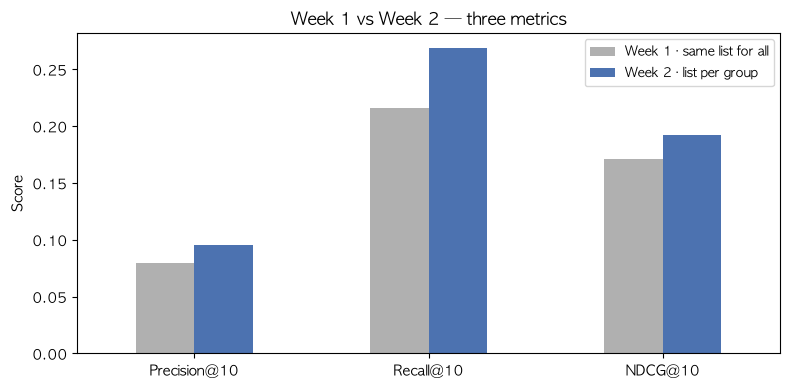

In [20]:
# 그래프를 그립니다. subplots 부터 show 까지는 한 셀에 붙어 있어야 그림이 한 번만 나옵니다.
fig, ax = plt.subplots(figsize=(8, 4))

# 그래프 글자는 영문으로 둡니다. 글꼴이 없는 환경에서도 안 깨집니다.
그래프용 = 결과.rename(index={
    "1주차 · 모두에게 같은 목록": "Week 1 · same list for all",
    "2주차 · 세그먼트별 목록": "Week 2 · list per group",
})

그래프용.T.plot(kind="bar", ax=ax, color=["#B0B0B0", "#4C72B0"], rot=0)
ax.set_ylabel("Score")
ax.set_title("Week 1 vs Week 2 — three metrics")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

세 지표 모두에서 2주차가 나았습니다.

지표를 바꿔도 결론이 뒤집히지 않았다는 뜻이므로, 이번 개선은 믿을 만합니다.

다만 항상 이렇지는 않습니다.

어떤 모델은 Precision 은 오르는데 Recall 은 떨어지기도 합니다.

그래서 **무엇을 중요하게 여길지 미리 정해 두는 것**이 중요합니다.

In [21]:
recsys.record(2, "취향이 비슷한 세그먼트끼리", 이번시간_점수,
              note="거래 기록으로 주력 섹터와 평균 위험도를 뽑아 세그먼트로 나눴다")

레벨 2 · 취향이 비슷한 세그먼트끼리 · Recall@10 = 0.2684


{'level': 2,
 'name': '취향이 비슷한 세그먼트끼리',
 'recall_at_10': 0.2684,
 'note': '거래 기록으로 주력 섹터와 평균 위험도를 뽑아 세그먼트로 나눴다'}

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.4 오늘의 마무리  `[PPT]`</mark>

거래 기록만 보고 사람을 무리로 나누었더니 점수가 올랐습니다.

성향 설문 같은 것을 따로 받지 않고도 "이 사람이 무엇을 좋아하는지"를 어느 정도 짐작할 수 있다는 뜻입니다.

그런데 아직 한계가 남아 있습니다.

**같은 무리에 속한 사람들은 여전히 똑같은 목록을 받습니다.**

`Index|3` 무리에 89명이 있다면 그 89명은 완전히 같은 추천을 받습니다.

사람마다 다른 추천이 되긴 했지만 무리 단위로만 달라진 것입니다.

그리고 더 신경 쓰이는 것이 하나 있습니다.

우리가 지금까지 재 온 점수가 **정말 믿을 만한 숫자인지** 아직 확인해 보지 않았습니다.

다음 시간에는 모델을 하나도 바꾸지 않고 채점 방법만 다시 들여다봅니다.

그런데 점수가 떨어집니다.